<a href="https://colab.research.google.com/github/h1baq1m/skills-getting-started-with-github-copilot/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# import the regression dataset and display first 5 records
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [12]:
# check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicates
print("Duplicates:\n", df.duplicated().sum())

Missing values:
 Gender    0
Height    0
Weight    0
dtype: int64
Duplicates:
 0


In [13]:
# encode the gender column using pd.get_dummies
df.info()

# Check if 'Gender' column exists before processing
if 'Gender' in df.columns:
    features = df[["Gender"]]
    new_features = pd.get_dummies(features)
    df.reset_index(inplace= True)
    new_features.reset_index(inplace= True)
    df = pd.merge(df,new_features,on="index",how="inner")
    df = df.drop(["index","Gender"],axis=1)
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


,Height,Weight,Gender_Female,Gender_Male
0,73.847017,241.893563,False,True
1,68.781904,162.310473,False,True


In [14]:
# examine the correlation between weight and height
correlation = df.corr()
print("Correlation:\n", correlation)

Correlation:
                  Height    Weight  Gender_Female  Gender_Male
Height         1.000000  0.924756      -0.691072     0.691072
Weight         0.924756  1.000000      -0.796723     0.796723
Gender_Female -0.691072 -0.796723       1.000000    -1.000000
Gender_Male    0.691072  0.796723      -1.000000     1.000000


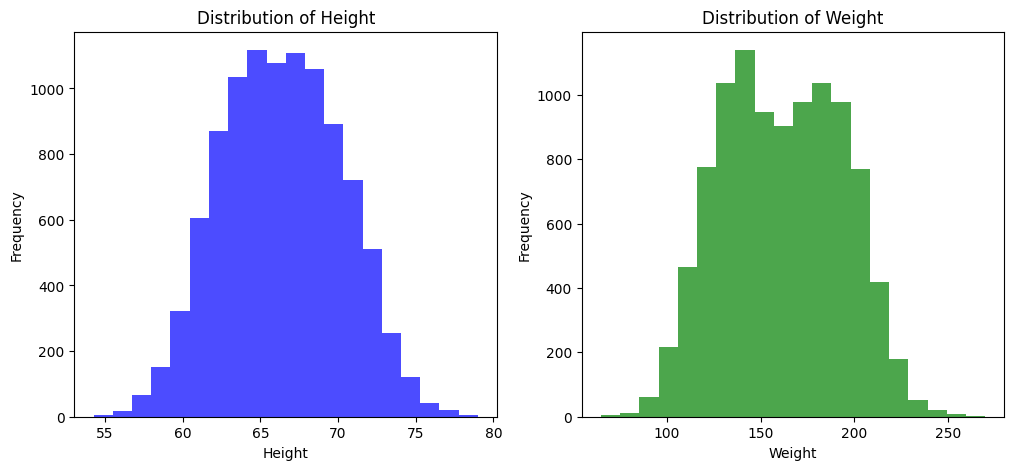

In [15]:
# observing the distribution
plt.figure(figsize=(12, 5))

# Distribution of Height
plt.subplot(1, 2, 1)
plt.hist(df["Height"], bins=20, color="blue", alpha=0.7)
plt.title("Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Frequency")

# Distribution of Weight
plt.subplot(1, 2, 2)
plt.hist(df["Weight"], bins=20, color="green", alpha=0.7)
plt.title("Distribution of Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

         Height      Weight  Gender_Female  Gender_Male  outlier
2014  78.998742  269.989699          False         True     True
Number of outliers: 1


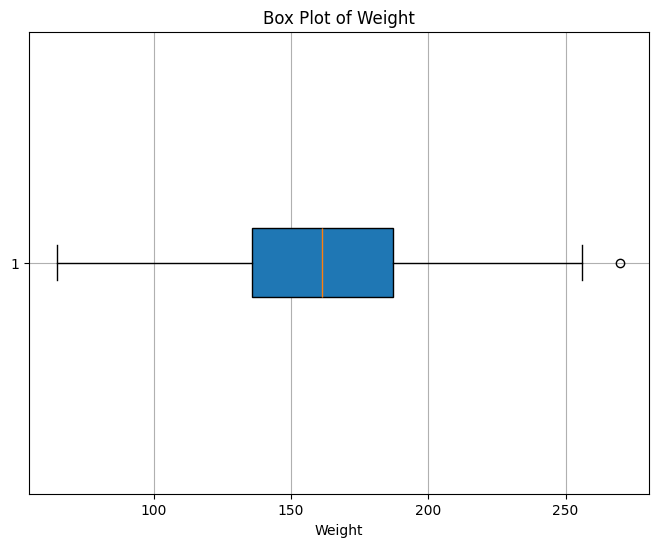

Number of rows: 9999


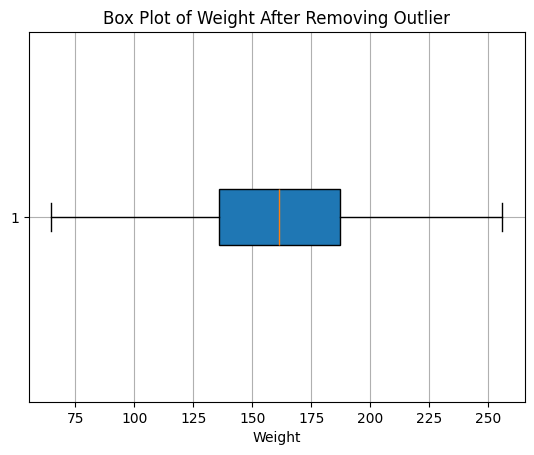

In [16]:
#Checking for outliers in the Weight records
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for identifying outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
df["outlier"] = (df["Weight"] < lower_bound) | (df["Weight"] > upper_bound)

# Display the outlier records
print(df[df["outlier"] == True])
print("Number of outliers:", df["outlier"].sum())

# Checking again to see if there are any outliers within a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df["Weight"], vert=False, patch_artist=True)
plt.title("Box Plot of Weight")
plt.xlabel("Weight")
plt.grid(True)
plt.show()

#drop the outliers
df = df[df["outlier"] == False]
df = df.drop("outlier", axis=1)


#check to see if the outlier has beem dropped
print("Number of rows:", df.shape[0])

plt.boxplot(df["Weight"], vert=False, patch_artist=True)
plt.title("Box Plot of Weight After Removing Outlier")
plt.xlabel("Weight")
plt.grid(True)
plt.show()

In [17]:
#make the model
x = df[["Height"]].values
y = df["Weight"].values

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.1)

In [18]:
#evaluating the models
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression MSE:", mse_linear)
print("Linear Regression R²:", r2_linear)

y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression MSE:", mse_lasso)
print("Lasso Regression R²:", r2_lasso)

y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression MSE:", mse_ridge)
print("Ridge Regression R²:", r2_ridge)



Linear Regression MSE: 144.656184669098
Linear Regression R²: 0.8644612873385703
Lasso Regression MSE: 144.67760964717235
Lasso Regression R²: 0.864441212746159
Ridge Regression MSE: 144.65620460470362
Ridge Regression R²: 0.8644612686594774


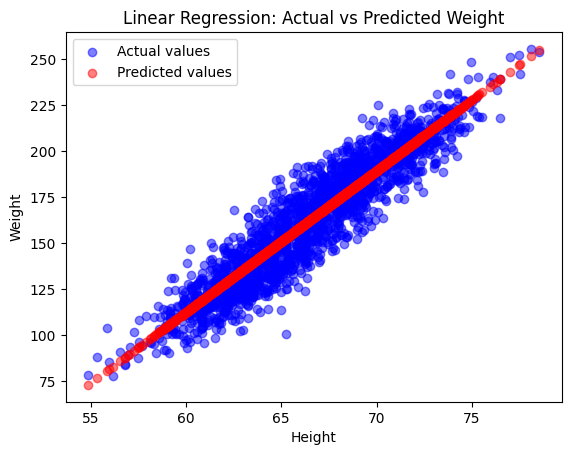

In [19]:
# visualisation of the Linear Regression predictions
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Actual values")
plt.scatter(X_test, y_pred_linear, color="red", alpha=0.5, label="Predicted values")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Linear Regression: Actual vs Predicted Weight")
plt.legend()
plt.show()